In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [3]:
path = '/my2026-fuel-consumption-ratings.csv'

In [4]:
df = pd.read_csv(path)

In [5]:
df.sample(5)

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
513,2026,Subaru,Ascent AWD,Sport utility vehicle: Standard,2.4,4,AV8,X,12.4,9.2,11.0,26,258,4,4
559,2026,Toyota,Land Cruiser,Sport utility vehicle: Standard,2.4,4,AS8,Z,10.7,9.5,10.1,28,237,5,5
204,2026,Ford,Mustang Dark Horse,Subcompact,5.0,8,AS10,X,16.5,10.9,13.9,20,326,3,2
557,2026,Toyota,Highlander Hybrid AWD,Sport utility vehicle: Standard,2.5,4,AV,X,6.7,6.8,6.7,42,158,6,6
19,2026,Audi,A5 TFSI quattro,Mid-size,2.0,4,AM7,Z,10.7,7.3,9.1,31,214,5,6


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model year            596 non-null    int64  
 1   Make                  596 non-null    object 
 2   Model                 596 non-null    object 
 3   Vehicle class         596 non-null    object 
 4   Engine size (L)       596 non-null    float64
 5   Cylinders             596 non-null    int64  
 6   Transmission          596 non-null    object 
 7   Fuel type             596 non-null    object 
 8   City (L/100 km)       596 non-null    float64
 9   Highway (L/100 km)    596 non-null    float64
 10  Combined (L/100 km)   596 non-null    float64
 11  Combined (mpg)        596 non-null    int64  
 12  CO2 emissions (g/km)  596 non-null    int64  
 13  CO2 rating            596 non-null    int64  
 14  Smog rating           596 non-null    int64  
dtypes: float64(4), int64(6)

In [13]:
df.describe()

,Model year,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
count,596.0,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000
mean,2026.0,3.003356,5.426174,12.081711,9.328691,10.844631,28.088926,254.337248,4.416107,4.979866
std,0.0,1.234527,1.845163,3.455832,2.270853,2.859316,8.398508,66.404075,1.330196,1.357060
min,2026.0,1.200000,3.000000,4.400000,4.400000,4.400000,14.000000,104.000000,1.000000,1.000000
25%,2026.0,2.000000,4.000000,9.700000,7.600000,8.700000,22.000000,204.000000,4.000000,4.000000
50%,2026.0,2.700000,4.000000,12.000000,9.200000,10.700000,26.000000,253.000000,4.000000,5.000000
75%,2026.0,3.500000,6.000000,14.325000,10.700000,12.700000,32.000000,298.000000,5.000000,6.000000
max,2026.0,6.700000,12.000000,23.500000,16.600000,19.700000,64.000000,460.000000,8.000000,7.000000


In [14]:
cdf = df[['Engine size (L)', 'Cylinders', 'Combined (L/100 km)', 'CO2 emissions (g/km)']]
cdf.sample(9)

,Engine size (L),Cylinders,Combined (L/100 km),CO2 emissions (g/km)
51,3.0,6,12.8,296
36,4.0,8,14.2,335
302,3.0,6,16.0,372
385,3.3,6,9.5,222
28,4.0,8,14.4,339
152,3.6,6,12.0,279
516,2.5,4,8.1,191
233,5.3,8,13.9,326
341,4.4,8,14.2,332


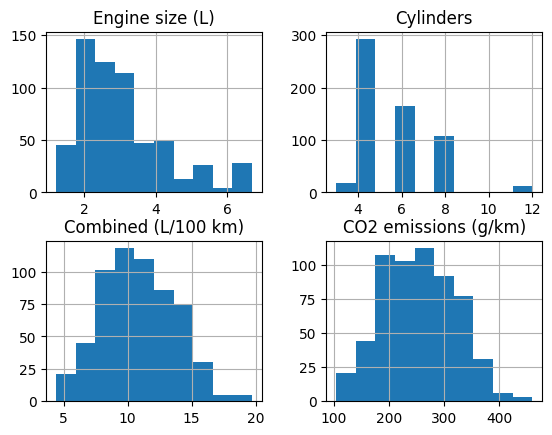

In [15]:
viz = cdf[['Engine size (L)', 'Cylinders', 'Combined (L/100 km)', 'CO2 emissions (g/km)']]
viz.hist()
plt.show()

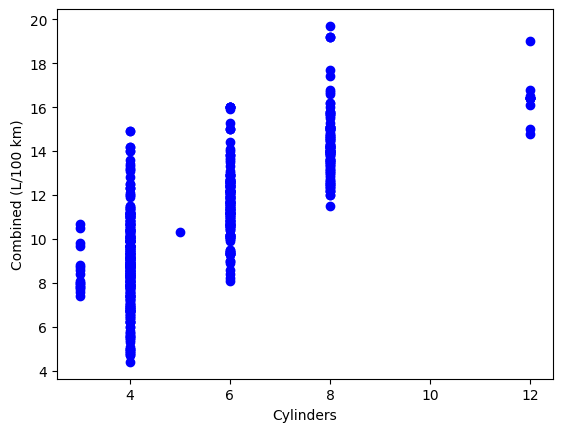

In [16]:
plt.scatter(cdf.Cylinders, cdf['Combined (L/100 km)'], color='blue')
plt.xlabel('Cylinders')
plt.ylabel('Combined (L/100 km)')
plt.show()

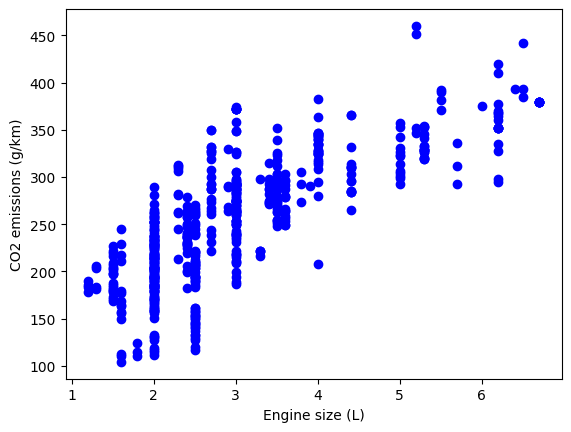

In [17]:
plt.scatter(cdf['Engine size (L)'], cdf['CO2 emissions (g/km)'], color='blue')
plt.xlabel('Engine size (L)')
plt.ylabel('CO2 emissions (g/km)')
plt.show()

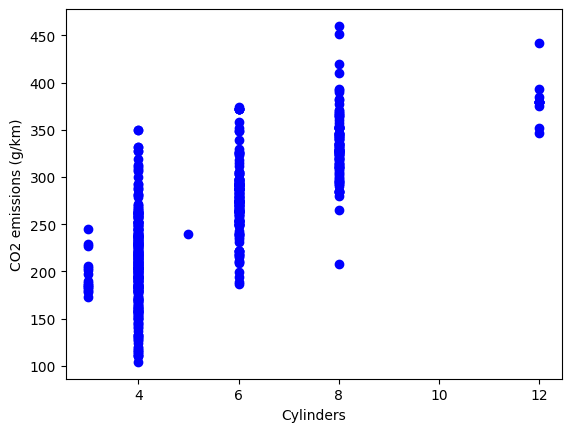

In [18]:
plt.scatter(cdf['Cylinders'], cdf['CO2 emissions (g/km)'], color='blue')
plt.xlabel('Cylinders')
plt.ylabel('CO2 emissions (g/km)')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = cdf['Engine size (L)'].to_numpy()
y = cdf['CO2 emissions (g/km)'].to_numpy()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
type(X_train) , np.shape(X_train), np.shape(y_train)

(numpy.ndarray, (476,), (476,))

In [26]:
print(X_train.reshape(-1,1).ndim) #2D
print(y_train.ndim) #1D

2
1


In [27]:
from sklearn import linear_model

regressor = linear_model.LinearRegression()

regressor.fit(X_train.reshape(-1,1), y_train)

print('Coefficients: ', regressor.coef_)
print('Intercept: ',regressor.intercept_)

Coefficients:  [40.90971263]
Intercept:  131.1023853375689


Text(0, 0.5, 'CO2 emissions (g/km)')

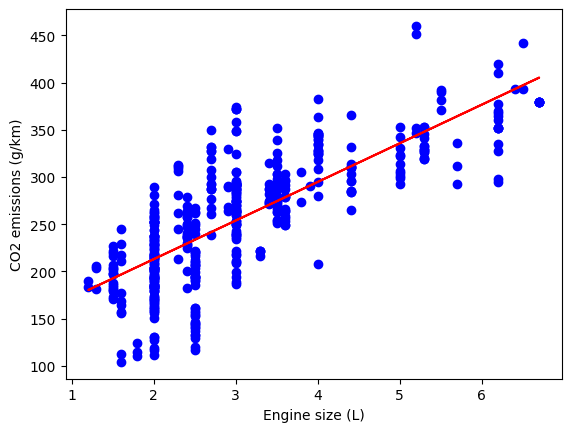

In [28]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel('Engine size (L)')
plt.ylabel('CO2 emissions (g/km)')

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score

y_pred = regressor.predict(X_test.reshape(-1,1))

print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error: ', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 Score: ', r2_score(y_test, y_pred))

Mean Absolute Error:  31.35313997745576
Mean Squared Error:  1739.1552678285996
Root Mean Squared Error:  41.70318054811407
R2 Score:  0.5977803339323331
